   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 29.1 MB/s eta 0:00:00
Please upload the CMEMS hourly current file: CMEMS_YilanBay_20240324_20240328_1hour.nc


Saving CMEMS_YilanBay_20240324_20240328_1hour.nc to CMEMS_YilanBay_20240324_20240328_1hour.nc

Required simulation period:
Start UTC: 2024-03-26 15:00:00
End UTC  : 2024-03-27 03:00:00

Available CMEMS period:
Start UTC: 2024-03-24 00:00:00
End UTC  : 2024-03-28 00:00:00


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)



Depth coordinate detected.
Depth level(s) present in uploaded hourly dataset:
[0.49402499]

Using the single available near-surface current level: 0.494025 m
No vertical averaging is applied.

Requested CMEMS download domain:
Longitude: 121.750000 to 122.650000°E
Latitude : 24.350000 to 25.250000°N

Actual valid CMEMS coordinate domain in uploaded file:
Longitude: 121.750015 to 122.583351°E
Latitude : 24.416666 to 25.250000°N

12-h estimated source centroid using hourly near-surface currents:
Latitude  = 24.417230°N
Longitude = 121.970681°E
Centroid displacement from Station 15 = 28.307 km

Particle stopping summary:
{'active_to_end': 0, 'stopped_by_land': 0, 'stopped_by_domain': 371, 'total_particles': 371}


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


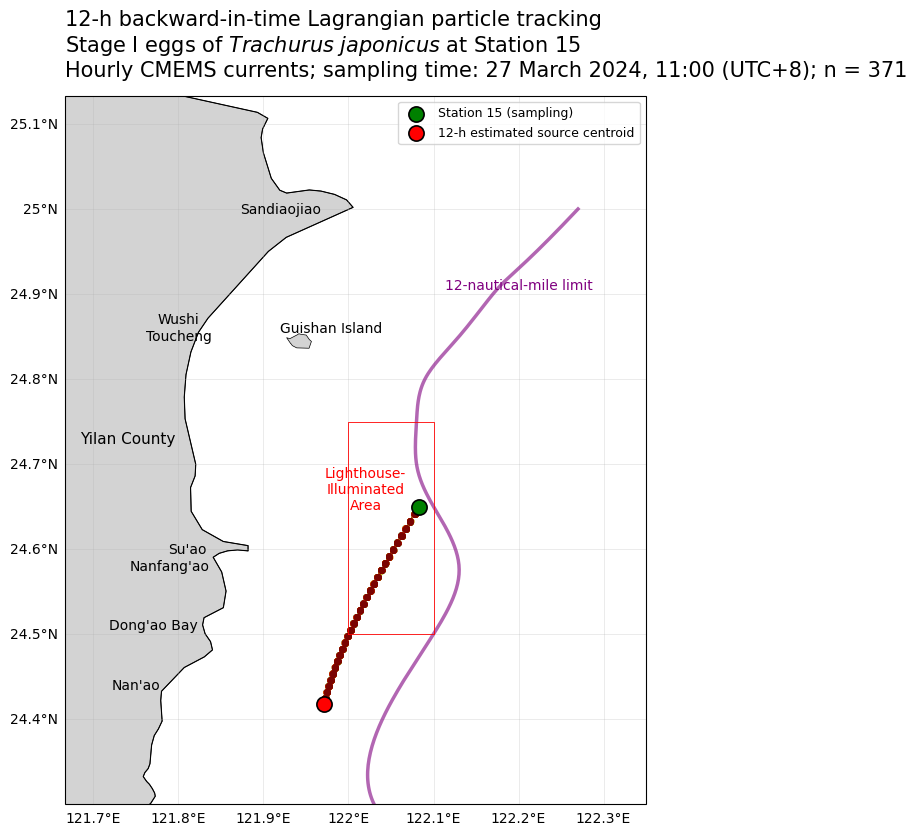


FINAL SIMULATION SUMMARY
Station: Station 15
Species: Trachurus japonicus
Particles: 371
Actual hourly-current depth used: 0.494025 m
Vertical averaging: NONE
Estimated source centroid: 24.417230°N, 121.970681°E
Centroid displacement: 28.307 km
Actual southernmost CMEMS grid: 24.416666°N

Particle stopping summary:
{'active_to_end': 0, 'stopped_by_land': 0, 'stopped_by_domain': 371, 'total_particles': 371}

Summary dataframe:


,station,species,stage,egg_number,sampling_time_UTC8,sampling_time_UTC,backtracking_duration_h,estimated_source_centroid_lat,estimated_source_centroid_lon,centroid_displacement_km,...,depth_level_used_m,vertical_velocity_treatment,time_step_s,integration_method,initial_particle_perturbation_radius_m,displayed_point_interval_min,random_seed,boundary_rule,centroid_definition,trajectory_display
0,Station 15,Trachurus japonicus,Stage I,371,2024-03-27 11:00,2024-03-27 03:00,12,24.41723,121.970681,28.306524,...,0.494025,Single near-surface depth level; no vertical a...,300,Second-order midpoint,50,20.0,20240602,Particles entering land or leaving the valid C...,Mean of the final valid ocean positions of all...,Faint lines plus sparse particle positions eve...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# Station 15 Trachurus japonicus Stage I eggs
# 12-h backward-in-time Lagrangian particle tracking
# CMEMS hourly near-surface current product
#
# IMPORTANT:
# This hourly CMEMS NetCDF contains a single near-surface
# velocity level. The actual depth coordinate is read directly
# from the uploaded NetCDF file. No vertical averaging is applied.
# ============================================================

!pip -q install xarray netCDF4 scipy pandas matplotlib cartopy shapely

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.interpolate import RegularGridInterpolator, make_interp_spline
from google.colab import files

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep


# ============================================================
# 1. Upload CMEMS hourly-current NetCDF
# ============================================================

EXPECTED_FILE = "CMEMS_YilanBay_20240324_20240328_1hour.nc"

print(f"Please upload the CMEMS hourly current file: {EXPECTED_FILE}")
uploaded = files.upload()

if EXPECTED_FILE in uploaded:
    nc_file = EXPECTED_FILE
else:
    nc_file = list(uploaded.keys())[0]
    print(f"\nWARNING: Expected filename not detected.")
    print(f"Using uploaded file instead: {nc_file}")

ds = xr.open_dataset(nc_file)


# ============================================================
# 2. Simulation settings
# ============================================================

species_label = r"$\it{Trachurus\ japonicus}$"

# Station 15
st_lat = 24.65
st_lon = 122.0833

# Number of Stage I eggs / particles
n_particles = 371

# Sampling time:
# 27 March 2024 11:00 UTC+8 = 27 March 2024 03:00 UTC
sample_time = np.datetime64("2024-03-27T03:00:00")

# Backtracking settings
duration_h = 12
dt_sec = 300                    # 5-min computational time step
point_stride = 4                # plot positions every 20 min
random_seed = 20240602
perturb_radius_m = 50

np.random.seed(random_seed)

# Requested CMEMS download domain
requested_lon_min = 121.75
requested_lon_max = 122.65
requested_lat_min = 24.35
requested_lat_max = 25.25

# Map extent for plotting
map_extent = [121.6666, 122.35, 24.3, 25.1333]


# ============================================================
# 3. Lighthouse-Illuminated Area (LIA)
# ============================================================

lia_lon_min = 122.0
lia_lon_max = 122.1
lia_lat_min = 24.5
lia_lat_max = 24.75


# ============================================================
# 4. Approximate 12-nautical-mile boundary
# ============================================================

limit12_lat_raw = np.array([
    25.00, 24.93, 24.90, 24.85, 24.80, 24.75,
    24.70, 24.65, 24.58, 24.50, 24.40, 24.30
])

limit12_lon_raw = np.array([
    122.27, 122.20, 122.17, 122.13, 122.09, 122.08,
    122.08, 122.10, 122.13, 122.10, 122.04, 122.03
])

t_raw = np.arange(len(limit12_lon_raw))
t_smooth = np.linspace(t_raw.min(), t_raw.max(), 300)

limit12_lon = make_interp_spline(
    t_raw, limit12_lon_raw, k=3
)(t_smooth)

limit12_lat = make_interp_spline(
    t_raw, limit12_lat_raw, k=3
)(t_smooth)


# ============================================================
# 5. Standardize coordinate names
# ============================================================

rename_dict = {}

if "lon" in ds.coords:
    rename_dict["lon"] = "longitude"

if "lat" in ds.coords:
    rename_dict["lat"] = "latitude"

if "time_counter" in ds.coords:
    rename_dict["time_counter"] = "time"

if rename_dict:
    ds = ds.rename(rename_dict)

if "uo" not in ds.variables or "vo" not in ds.variables:
    raise ValueError(
        "Variables 'uo' and/or 'vo' were not found. "
        "Please confirm that the uploaded file is the CMEMS hourly current dataset."
    )

ds["time"] = pd.to_datetime(ds["time"].values)

# Convert longitude to -180 to 180 if necessary
if float(ds["longitude"].max()) > 180:
    ds = ds.assign_coords(
        longitude=(((ds["longitude"] + 180) % 360) - 180)
    )

ds = ds.sortby("longitude").sortby("latitude")


# ============================================================
# 6. Verify simulation time coverage
# ============================================================

needed_start = sample_time - np.timedelta64(duration_h, "h")
needed_end = sample_time

print("\nRequired simulation period:")
print("Start UTC:", pd.Timestamp(needed_start))
print("End UTC  :", pd.Timestamp(needed_end))

print("\nAvailable CMEMS period:")
print("Start UTC:", pd.Timestamp(ds.time.values[0]))
print("End UTC  :", pd.Timestamp(ds.time.values[-1]))

if pd.Timestamp(ds.time.values[0]) > pd.Timestamp(needed_start):
    raise ValueError(
        "The NetCDF file starts too late to support the 12-h backtracking simulation."
    )

if pd.Timestamp(ds.time.values[-1]) < pd.Timestamp(needed_end):
    raise ValueError(
        "The NetCDF file ends too early to support the 12-h backtracking simulation."
    )


# ============================================================
# 7. Natural Earth land mask
# ============================================================

land_shp = shpreader.natural_earth(
    resolution="10m",
    category="physical",
    name="land"
)

land_union = unary_union(
    list(shpreader.Reader(land_shp).geometries())
)

land_prepared = prep(land_union)


def is_land(lon, lat):
    return land_prepared.contains(
        Point(float(lon), float(lat))
    )


def is_land_array(lons, lats):
    return np.array(
        [
            is_land(lon, lat)
            for lon, lat in zip(lons, lats)
        ],
        dtype=bool
    )


if is_land(st_lon, st_lat):
    raise ValueError(
        "Station 15 is classified as land by the land mask. "
        "Please check the station coordinates."
    )


# ============================================================
# 8. Hourly CMEMS vertical-level handling
#
# IMPORTANT:
# The hourly sensitivity dataset used here should contain
# one near-surface depth level only.
#
# The actual depth is read directly from the NetCDF.
# NO nominal 0.49-34.43 m selection is applied.
# NO vertical averaging is performed.
# ============================================================

if "depth" in ds.coords or "depth" in ds.dims:

    depth_values = np.atleast_1d(
        ds["depth"].values
    ).astype(float).ravel()

    print("\nDepth coordinate detected.")
    print("Depth level(s) present in uploaded hourly dataset:")
    print(depth_values)

    if len(depth_values) != 1:
        raise ValueError(
            "This hourly sensitivity-analysis workflow expects exactly "
            "one near-surface depth level, but the uploaded dataset "
            f"contains {len(depth_values)} depth levels: {depth_values}. "
            "Please verify that the correct hourly CMEMS file was uploaded."
        )

    depth_level_used_m = float(depth_values[0])

    print(
        f"\nUsing the single available near-surface current level: "
        f"{depth_level_used_m:.6f} m"
    )
    print("No vertical averaging is applied.")

    # Remove the singleton depth dimension explicitly.
    # This does NOT average vertically.
    u_da = ds["uo"].isel(depth=0, drop=True)
    v_da = ds["vo"].isel(depth=0, drop=True)

    vertical_velocity_treatment = (
        "Single near-surface depth level; no vertical averaging"
    )

else:
    raise ValueError(
        "No depth coordinate was found in the uploaded hourly CMEMS file. "
        "Please verify that the correct dataset was uploaded."
    )


# ============================================================
# 9. Report actual CMEMS grid domain
# ============================================================

actual_lon_min = float(ds.longitude.min())
actual_lon_max = float(ds.longitude.max())
actual_lat_min = float(ds.latitude.min())
actual_lat_max = float(ds.latitude.max())

print("\nRequested CMEMS download domain:")
print(
    f"Longitude: {requested_lon_min:.6f} to "
    f"{requested_lon_max:.6f}°E"
)
print(
    f"Latitude : {requested_lat_min:.6f} to "
    f"{requested_lat_max:.6f}°N"
)

print("\nActual valid CMEMS coordinate domain in uploaded file:")
print(
    f"Longitude: {actual_lon_min:.6f} to "
    f"{actual_lon_max:.6f}°E"
)
print(
    f"Latitude : {actual_lat_min:.6f} to "
    f"{actual_lat_max:.6f}°N"
)


# ============================================================
# 10. Prepare current fields for interpolation
# ============================================================

u_da = u_da.transpose(
    "time", "latitude", "longitude"
)

v_da = v_da.transpose(
    "time", "latitude", "longitude"
)

time_vals = pd.to_datetime(
    u_da["time"].values
)

time_sec = (
    (time_vals - pd.Timestamp("1970-01-01"))
    / pd.Timedelta(seconds=1)
).astype(float)

lat_vals = u_da["latitude"].values.astype(float)
lon_vals = u_da["longitude"].values.astype(float)

u_interp = RegularGridInterpolator(
    (time_sec, lat_vals, lon_vals),
    u_da.values.astype(float),
    bounds_error=False,
    fill_value=np.nan
)

v_interp = RegularGridInterpolator(
    (time_sec, lat_vals, lon_vals),
    v_da.values.astype(float),
    bounds_error=False,
    fill_value=np.nan
)


def datetime64_to_seconds(t):
    return float(
        (
            pd.Timestamp(t)
            - pd.Timestamp("1970-01-01")
        )
        / pd.Timedelta(seconds=1)
    )


def get_uv(time_np64, lats, lons):

    pts = np.column_stack([
        np.full(
            len(lats),
            datetime64_to_seconds(time_np64),
            dtype=float
        ),
        np.asarray(lats, dtype=float),
        np.asarray(lons, dtype=float)
    ])

    return u_interp(pts), v_interp(pts)


# ============================================================
# 11. Initialize particles within 50 m of sampling station
# ============================================================

def initialize_particles(
    lon0,
    lat0,
    n,
    radius_m=50
):

    theta = np.random.uniform(
        0,
        2 * np.pi,
        n
    )

    # Uniform distribution over a circular area
    r = radius_m * np.sqrt(
        np.random.uniform(0, 1, n)
    )

    dx = r * np.cos(theta)
    dy = r * np.sin(theta)

    lons = (
        lon0
        + dx
        / (
            111320.0
            * np.cos(np.deg2rad(lat0))
        )
    )

    lats = (
        lat0
        + dy / 111320.0
    )

    return lons, lats


# ============================================================
# 12. Backward-in-time advection
#
# Second-order midpoint integration.
#
# A particle is terminated when:
# 1. interpolated current data become invalid,
# 2. it reaches land, or
# 3. it leaves the valid CMEMS data domain.
#
# Its last valid ocean position is retained.
# ============================================================

def advect_backward_with_land_stop(duration_h):

    n_steps = int(
        duration_h * 3600 / dt_sec
    )

    lons, lats = initialize_particles(
        st_lon,
        st_lat,
        n_particles,
        perturb_radius_m
    )

    traj_lon = np.full(
        (n_steps + 1, n_particles),
        np.nan
    )

    traj_lat = np.full(
        (n_steps + 1, n_particles),
        np.nan
    )

    traj_lon[0, :] = lons
    traj_lat[0, :] = lats

    active = np.ones(
        n_particles,
        dtype=bool
    )

    last_valid_lon = lons.copy()
    last_valid_lat = lats.copy()

    stopped_by_land = np.zeros(
        n_particles,
        dtype=bool
    )

    stopped_by_domain = np.zeros(
        n_particles,
        dtype=bool
    )

    lon_min = actual_lon_min
    lon_max = actual_lon_max
    lat_min = actual_lat_min
    lat_max = actual_lat_max

    current_time = sample_time

    for k in range(n_steps):

        # Negative time step = backward integration
        dt = -dt_sec

        idx = np.where(active)[0]

        if len(idx) == 0:
            break

        cur_lons = lons[idx]
        cur_lats = lats[idx]

        # ----------------------------------------------------
        # First velocity evaluation
        # ----------------------------------------------------

        u1, v1 = get_uv(
            current_time,
            cur_lats,
            cur_lons
        )

        valid1 = ~(
            np.isnan(u1)
            | np.isnan(v1)
        )

        if not np.all(valid1):

            bad_idx = idx[~valid1]

            active[bad_idx] = False
            stopped_by_domain[bad_idx] = True

            idx = idx[valid1]
            cur_lons = cur_lons[valid1]
            cur_lats = cur_lats[valid1]
            u1 = u1[valid1]
            v1 = v1[valid1]

        if len(idx) == 0:

            current_time += np.timedelta64(
                dt,
                "s"
            )

            continue

        # ----------------------------------------------------
        # Midpoint
        # ----------------------------------------------------

        lon_mid = (
            cur_lons
            + 0.5
            * dt
            * u1
            / (
                111320.0
                * np.cos(
                    np.deg2rad(cur_lats)
                )
            )
        )

        lat_mid = (
            cur_lats
            + 0.5
            * dt
            * v1
            / 111320.0
        )

        time_mid = (
            current_time
            + np.timedelta64(
                int(dt / 2),
                "s"
            )
        )

        # ----------------------------------------------------
        # Midpoint velocity evaluation
        # ----------------------------------------------------

        u2, v2 = get_uv(
            time_mid,
            lat_mid,
            lon_mid
        )

        valid2 = ~(
            np.isnan(u2)
            | np.isnan(v2)
        )

        if not np.all(valid2):

            bad_idx = idx[~valid2]

            active[bad_idx] = False
            stopped_by_domain[bad_idx] = True

            idx = idx[valid2]
            cur_lons = cur_lons[valid2]
            cur_lats = cur_lats[valid2]
            lat_mid = lat_mid[valid2]
            u2 = u2[valid2]
            v2 = v2[valid2]

        if len(idx) == 0:

            current_time += np.timedelta64(
                dt,
                "s"
            )

            continue

        # ----------------------------------------------------
        # Final midpoint-method position
        # ----------------------------------------------------

        new_lons = (
            cur_lons
            + dt
            * u2
            / (
                111320.0
                * np.cos(
                    np.deg2rad(lat_mid)
                )
            )
        )

        new_lats = (
            cur_lats
            + dt
            * v2
            / 111320.0
        )

        # ----------------------------------------------------
        # Land / domain checks
        # ----------------------------------------------------

        on_land = is_land_array(
            new_lons,
            new_lats
        )

        inside_domain = (
            (new_lons >= lon_min)
            & (new_lons <= lon_max)
            & (new_lats >= lat_min)
            & (new_lats <= lat_max)
        )

        valid_move = (
            (~on_land)
            & inside_domain
        )

        if not np.all(valid_move):

            bad_idx = idx[~valid_move]

            active[bad_idx] = False

            stopped_by_land[bad_idx] = (
                on_land[~valid_move]
            )

            stopped_by_domain[bad_idx] = (
                stopped_by_domain[bad_idx]
                | (~inside_domain[~valid_move])
            )

        good_idx = idx[valid_move]

        lons[good_idx] = (
            new_lons[valid_move]
        )

        lats[good_idx] = (
            new_lats[valid_move]
        )

        last_valid_lon[good_idx] = (
            lons[good_idx]
        )

        last_valid_lat[good_idx] = (
            lats[good_idx]
        )

        traj_lon[k + 1, good_idx] = (
            lons[good_idx]
        )

        traj_lat[k + 1, good_idx] = (
            lats[good_idx]
        )

        current_time += np.timedelta64(
            dt,
            "s"
        )

    # Centroid of each particle's final valid ocean position
    centroid_lon = float(
        np.mean(last_valid_lon)
    )

    centroid_lat = float(
        np.mean(last_valid_lat)
    )

    stop_summary = {
        "active_to_end":
            int(np.sum(active)),

        "stopped_by_land":
            int(np.sum(stopped_by_land)),

        "stopped_by_domain":
            int(np.sum(stopped_by_domain)),

        "total_particles":
            int(n_particles)
    }

    return (
        traj_lon,
        traj_lat,
        centroid_lon,
        centroid_lat,
        last_valid_lon,
        last_valid_lat,
        stop_summary
    )


# ============================================================
# 13. Run 12-h simulation
# ============================================================

(
    traj_lon,
    traj_lat,
    cen_lon,
    cen_lat,
    last_lon,
    last_lat,
    stop_summary
) = advect_backward_with_land_stop(
    duration_h
)


# ============================================================
# 14. Centroid displacement
# ============================================================

disp_km = np.sqrt(

    (
        (cen_lon - st_lon)
        * 111.32
        * np.cos(np.deg2rad(st_lat))
    ) ** 2

    +

    (
        (cen_lat - st_lat)
        * 111.32
    ) ** 2
)


print(
    f"\n{duration_h}-h estimated source centroid "
    f"using hourly near-surface currents:"
)

print(
    f"Latitude  = {cen_lat:.6f}°N"
)

print(
    f"Longitude = {cen_lon:.6f}°E"
)

print(
    f"Centroid displacement from Station 15 "
    f"= {disp_km:.3f} km"
)

print("\nParticle stopping summary:")
print(stop_summary)


# ============================================================
# 15. Map labels
# ============================================================

place_labels = [

    ("Sandiaojiao",
     121.92, 25.00, 10),

    ("Wushi",
     121.80, 24.87, 10),

    ("Toucheng",
     121.80, 24.85, 10),

    ("Guishan Island",
     121.98, 24.86, 10),

    ("Yilan County",
     121.74, 24.73, 11),

    ("Su'ao",
     121.81, 24.60, 10),

    ("Nanfang'ao",
     121.79, 24.58, 10),

    ("Dong'ao Bay",
     121.77, 24.51, 10),

    ("Nan'ao",
     121.75, 24.44, 10),
]


# ============================================================
# 16. Plot
# ============================================================

fig = plt.figure(
    figsize=(8.2, 9.2)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.set_extent(
    map_extent,
    crs=ccrs.PlateCarree()
)

ax.add_feature(
    cfeature.LAND,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.5,
    zorder=0
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.8,
    zorder=1
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    alpha=0.35
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.MultipleLocator(0.1)
gl.ylocator = mticker.MultipleLocator(0.1)

gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}


# ------------------------------------------------------------
# 12-nautical-mile boundary
# ------------------------------------------------------------

ax.plot(
    limit12_lon,
    limit12_lat,
    color="purple",
    linewidth=2.5,
    alpha=0.60,
    transform=ccrs.PlateCarree(),
    zorder=2
)

ax.text(
    122.20,
    24.91,
    "12-nautical-mile limit",
    fontsize=10,
    color="purple",
    ha="center",
    va="center",
    transform=ccrs.PlateCarree(),
    zorder=10
)


# ------------------------------------------------------------
# Lighthouse-Illuminated Area
# ------------------------------------------------------------

lia_lons = [
    lia_lon_min,
    lia_lon_max,
    lia_lon_max,
    lia_lon_min,
    lia_lon_min
]

lia_lats = [
    lia_lat_min,
    lia_lat_min,
    lia_lat_max,
    lia_lat_max,
    lia_lat_min
]

ax.plot(
    lia_lons,
    lia_lats,
    color="red",
    linewidth=0.6,
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.text(
    122.02,
    24.67,
    "Lighthouse-\nIlluminated\nArea",
    fontsize=10,
    color="red",
    ha="center",
    va="center",
    transform=ccrs.PlateCarree(),
    zorder=10
)


# ------------------------------------------------------------
# Particle trajectories
# ------------------------------------------------------------

colors = plt.cm.turbo(
    np.linspace(
        0,
        1,
        n_particles
    )
)

for i in range(n_particles):

    valid = (
        ~np.isnan(traj_lon[:, i])
        & ~np.isnan(traj_lat[:, i])
    )

    ax.plot(
        traj_lon[valid, i],
        traj_lat[valid, i],
        color=colors[i],
        linewidth=0.35,
        alpha=0.20,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    valid_indices = np.where(valid)[0]

    sparse_indices = (
        valid_indices[::point_stride]
    )

    ax.scatter(
        traj_lon[sparse_indices, i],
        traj_lat[sparse_indices, i],
        s=12,
        color=colors[i],
        alpha=0.70,
        transform=ccrs.PlateCarree(),
        zorder=4
    )


# ------------------------------------------------------------
# Sampling station
# ------------------------------------------------------------

ax.scatter(
    st_lon,
    st_lat,
    s=120,
    facecolor="green",
    edgecolor="black",
    linewidth=1.2,
    transform=ccrs.PlateCarree(),
    zorder=8,
    label="Station 15 (sampling)"
)


# ------------------------------------------------------------
# Final-valid-position centroid
# ------------------------------------------------------------

ax.scatter(
    cen_lon,
    cen_lat,
    s=120,
    facecolor="red",
    edgecolor="black",
    linewidth=1.2,
    transform=ccrs.PlateCarree(),
    zorder=9,
    label="12-h estimated source centroid"
)


# ------------------------------------------------------------
# Place labels
# ------------------------------------------------------------

for name, lon, lat, fsize in place_labels:

    ax.text(
        lon,
        lat,
        name,
        fontsize=fsize,
        ha="center",
        va="center",
        transform=ccrs.PlateCarree(),
        zorder=10
    )


# ============================================================
# 17. Figure title
# ============================================================

title = (

    f"12-h backward-in-time Lagrangian particle tracking\n"

    f"Stage I eggs of {species_label} at Station 15\n"

    f"Hourly CMEMS currents; sampling time: "
    f"27 March 2024, 11:00 (UTC+8); n = 371"
)

ax.set_title(
    title,
    fontsize=15,
    loc="left",
    pad=14
)

ax.legend(
    loc="upper right",
    fontsize=9,
    frameon=True
)


# ============================================================
# 18. Save figure
# ============================================================

out_png = (
    "St15_Tjaponicus_backtracking_12h_"
    "hourly_current_landmask_LIA_12nmi.png"
)

plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. Create corrected summary CSV
#
# IMPORTANT:
# The metadata below reports the ACTUAL single depth level
# used by the simulation. It does not report a nominal
# 0.49-34.43 m selection range.
# ============================================================

summary_df = pd.DataFrame([{

    "station":
        "Station 15",

    "species":
        "Trachurus japonicus",

    "stage":
        "Stage I",

    "egg_number":
        n_particles,

    "sampling_time_UTC8":
        "2024-03-27 11:00",

    "sampling_time_UTC":
        "2024-03-27 03:00",

    "backtracking_duration_h":
        duration_h,

    "estimated_source_centroid_lat":
        cen_lat,

    "estimated_source_centroid_lon":
        cen_lon,

    "centroid_displacement_km":
        disp_km,

    "active_to_end":
        stop_summary["active_to_end"],

    "stopped_by_land":
        stop_summary["stopped_by_land"],

    "stopped_by_domain":
        stop_summary["stopped_by_domain"],

    "current_product":
        "GLOBAL_ANALYSISFORECAST_PHY_001_024",

    "current_dataset":
        "cmems_mod_glo_phy_anfc_0.083deg_PT1H-m",

    "current_file":
        EXPECTED_FILE,

    "current_temporal_resolution":
        "hourly",

    "requested_current_area":
        (
            f"{requested_lon_min}-{requested_lon_max}E, "
            f"{requested_lat_min}-{requested_lat_max}N"
        ),

    "actual_grid_lon_min":
        actual_lon_min,

    "actual_grid_lon_max":
        actual_lon_max,

    "actual_grid_lat_min":
        actual_lat_min,

    "actual_grid_lat_max":
        actual_lat_max,

    "current_time_range_UTC":
        "2024-03-24 00:00 to 2024-03-28 00:00",

    "depth_level_used_m":
        depth_level_used_m,

    "vertical_velocity_treatment":
        vertical_velocity_treatment,

    "time_step_s":
        dt_sec,

    "integration_method":
        "Second-order midpoint",

    "initial_particle_perturbation_radius_m":
        perturb_radius_m,

    "displayed_point_interval_min":
        point_stride * dt_sec / 60,

    "random_seed":
        random_seed,

    "boundary_rule":
        (
            "Particles entering land or leaving the valid "
            "CMEMS data domain were stopped at their last "
            "valid ocean position."
        ),

    "centroid_definition":
        (
            "Mean of the final valid ocean positions "
            "of all particles."
        ),

    "trajectory_display":
        (
            "Faint lines plus sparse particle positions "
            "every 20 minutes."
        )

}])


# ============================================================
# 20. Save summary CSV
# ============================================================

summary_csv = (
    "St15_Tjaponicus_backtracking_"
    "12h_hourly_current_summary.csv"
)

summary_df.to_csv(
    summary_csv,
    index=False
)


# ============================================================
# 21. Display final checks
# ============================================================

print("\n============================================")
print("FINAL SIMULATION SUMMARY")
print("============================================")

print(
    f"Station: Station 15"
)

print(
    f"Species: Trachurus japonicus"
)

print(
    f"Particles: {n_particles}"
)

print(
    f"Actual hourly-current depth used: "
    f"{depth_level_used_m:.6f} m"
)

print(
    "Vertical averaging: NONE"
)

print(
    f"Estimated source centroid: "
    f"{cen_lat:.6f}°N, {cen_lon:.6f}°E"
)

print(
    f"Centroid displacement: "
    f"{disp_km:.3f} km"
)

print(
    f"Actual southernmost CMEMS grid: "
    f"{actual_lat_min:.6f}°N"
)

print("\nParticle stopping summary:")
print(stop_summary)

print("\nSummary dataframe:")
display(summary_df)


# ============================================================
# 22. Automatic downloads
# ============================================================

print("\nDownloading output files...")

files.download(out_png)
files.download(summary_csv)